![Add a relevant banner image here](path_to_image)

# Project Title

# US Traffic Accidents 

## Overview

Short project description. Your bottom line up front (BLUF) insights.

## Business Understanding

Traffic Accidents create big impact to safety, financial, and damages to the infrastructure in the US. The United States department of transportation (DOT), Emergency response professional, City Planners, Car Manufacturer, and Car insurance companies can benefit from The US Traffic Accidents to understand the pattern Traffic accidents in the US. The US Traffic Accidents Dataset has Weather Conditions, Time of day, the severity of accident, accident description, and also accident road circumstance (like roundabout, Stop sign, Railway, Traffic light, ect). The features of the dataset fit well to predict the classification of severity.
The main business problem that this project is try to address is the understanding what accident condition can lead to severe accidents types. By look at the past accident dataset organization can make informed decision that can make better infrastructure, lower risk for better pricing for insurance policy, and better plaining for Emergency response professional to help save time and lives. 
Key Stakeholder are department of transportation (DOT) for the states who need the this data to apply the traffic infrastructure, Emergency response professional to understand what to expect for a certain type of accident, and Insurance companies that the risk analysis data to feed their models to make their pricing the drivers area. 
To help the stake holders this Project is going to answer these question.
- What is the impact of Weather on Severity?
- What is the relationship between Road feature and Severity?
- Comparing SC to the US average to insight on why is so high giving it one of the least populated states? 

By doing these analysis the stakeholders can get som key insight to improve their decision making, save lives, and save the tax payers money.

 

## Data Understanding

Text here

In [1]:
# Load relevant imports here
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [54]:
#Loading the Data from the CSV
us_accidents_df = pd.read_csv("Data/US_Accidents_March23.csv")

In [55]:
# Look at the data set
us_accidents_df.head()

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,NaN,NaN,0.01,...,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,NaN,NaN,0.01,...,False,False,False,False,True,False,Day,Day,Day,Day


In [56]:
#Looking at the data type with the column
us_accidents_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7728394 entries, 0 to 7728393
Data columns (total 46 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   ID                     object 
 1   Source                 object 
 2   Severity               int64  
 3   Start_Time             object 
 4   End_Time               object 
 5   Start_Lat              float64
 6   Start_Lng              float64
 7   End_Lat                float64
 8   End_Lng                float64
 9   Distance(mi)           float64
 10  Description            object 
 11  Street                 object 
 12  City                   object 
 13  County                 object 
 14  State                  object 
 15  Zipcode                object 
 16  Country                object 
 17  Timezone               object 
 18  Airport_Code           object 
 19  Weather_Timestamp      object 
 20  Temperature(F)         float64
 21  Wind_Chill(F)          float64
 22  Humidity(%)       

In [57]:
# Listing the column names 
us_accidents_df.columns

Index(['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat',
       'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Description',
       'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone',
       'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)',
       'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction',
       'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity',
       'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway',
       'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal',
       'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
       'Astronomical_Twilight'],
      dtype='object')

In [58]:
us_accidents_df.isnull().sum()

ID                             0
Source                         0
Severity                       0
Start_Time                     0
End_Time                       0
Start_Lat                      0
Start_Lng                      0
End_Lat                  3402762
End_Lng                  3402762
Distance(mi)                   0
Description                    5
Street                     10869
City                         253
County                         0
State                          0
Zipcode                     1915
Country                        0
Timezone                    7808
Airport_Code               22635
Weather_Timestamp         120228
Temperature(F)            163853
Wind_Chill(F)            1999019
Humidity(%)               174144
Pressure(in)              140679
Visibility(mi)            177098
Wind_Direction            175206
Wind_Speed(mph)           571233
Precipitation(in)        2203586
Weather_Condition         173459
Amenity                        0
Bump      

In [59]:
missing = us_accidents_df.isnull().sum().sort_values(ascending=False)
percent = (us_accidents_df.isnull().mean() * 100).sort_values(ascending=False)

missing_df = pd.DataFrame({
    'Missing Values': missing,
    'Percent Missing': percent
})

missing_df


,Missing Values,Percent Missing
End_Lat,3402762,44.029355
End_Lng,3402762,44.029355
Precipitation(in),2203586,28.512858
Wind_Chill(F),1999019,25.865904
Wind_Speed(mph),571233,7.391355
Visibility(mi),177098,2.291524
Wind_Direction,175206,2.267043
Humidity(%),174144,2.253301
Weather_Condition,173459,2.244438
Temperature(F),163853,2.120143


## Data Preparation
Text here

In [60]:
# Im dropping these columns b
cols_to_drop = [
    'ID',
    'Source',
    'End_Lat',
    'End_Lng',
    'End_Time',
    'Zipcode',
    'Country',
    'Airport_Code',
    'Weather_Timestamp',
]

us_accidents_df = us_accidents_df.drop(columns=cols_to_drop)

In [61]:
missing = us_accidents_df.isnull().sum().sort_values(ascending=False)
percent = (us_accidents_df.isnull().mean() * 100).sort_values(ascending=False)

missing_df = pd.DataFrame({
    'Missing Values': missing,
    'Percent Missing': percent
})

missing_df

,Missing Values,Percent Missing
Precipitation(in),2203586,28.512858
Wind_Chill(F),1999019,25.865904
Wind_Speed(mph),571233,7.391355
Visibility(mi),177098,2.291524
Wind_Direction,175206,2.267043
Humidity(%),174144,2.253301
Weather_Condition,173459,2.244438
Temperature(F),163853,2.120143
Pressure(in),140679,1.820288
Nautical_Twilight,23246,0.300787


In [62]:
us_accidents_df['Description_len'] = us_accidents_df['Description'].str.len()
us_accidents_df['Description_len'].describe()

count    7.728389e+06
mean     6.883716e+01
std      3.107007e+01
min      2.000000e+00
25%      4.700000e+01
50%      6.200000e+01
75%      8.500000e+01
max      6.790000e+02
Name: Description_len, dtype: float64

In [63]:
us_accidents_df['Start_Time'] = pd.to_datetime(us_accidents_df['Start_Time'], format='mixed', errors= 'coerce')


In [64]:
us_accidents_df['Start_Time'].head()


0   2016-02-08 05:46:00
1   2016-02-08 06:07:59
2   2016-02-08 06:49:27
3   2016-02-08 07:23:34
4   2016-02-08 07:39:07
Name: Start_Time, dtype: datetime64[ns]

In [65]:
us_accidents_df['Start_Time'].isna().sum()

0

In [66]:
us_accidents_df['Year'] = us_accidents_df['Start_Time'].dt.year
us_accidents_df['Month'] = us_accidents_df['Start_Time'].dt.month
us_accidents_df['Hour'] = us_accidents_df['Start_Time'].dt.hour
us_accidents_df['Weekday'] = us_accidents_df['Start_Time'].dt.day_name()

In [67]:
us_accidents_df[['Start_Time','Month','Year','Hour','Weekday']].head()

,Start_Time,Month,Year,Hour,Weekday
0,2016-02-08 05:46:00,2,2016,5,Monday
1,2016-02-08 06:07:59,2,2016,6,Monday
2,2016-02-08 06:49:27,2,2016,6,Monday
3,2016-02-08 07:23:34,2,2016,7,Monday
4,2016-02-08 07:39:07,2,2016,7,Monday


## Analysis

Text here

In [68]:
us_accidents_df['Severity'].value_counts()

Severity
2    6156981
3    1299337
4     204710
1      67366
Name: count, dtype: int64

### Do Weather impact Accident Severity

In [69]:
us_accidents_df['Weather_Condition'].unique()

array(['Light Rain', 'Overcast', 'Mostly Cloudy', 'Rain', 'Light Snow',
       'Haze', 'Scattered Clouds', 'Partly Cloudy', 'Clear', 'Snow',
       'Light Freezing Drizzle', 'Light Drizzle', 'Fog', 'Shallow Fog',
       'Heavy Rain', 'Light Freezing Rain', 'Cloudy', 'Drizzle', nan,
       'Light Rain Showers', 'Mist', 'Smoke', 'Patches of Fog',
       'Light Freezing Fog', 'Light Haze', 'Light Thunderstorms and Rain',
       'Thunderstorms and Rain', 'Fair', 'Volcanic Ash', 'Blowing Sand',
       'Blowing Dust / Windy', 'Widespread Dust', 'Fair / Windy',
       'Rain Showers', 'Mostly Cloudy / Windy', 'Light Rain / Windy',
       'Hail', 'Heavy Drizzle', 'Showers in the Vicinity', 'Thunderstorm',
       'Light Rain Shower', 'Light Rain with Thunder',
       'Partly Cloudy / Windy', 'Thunder in the Vicinity', 'T-Storm',
       'Heavy Thunderstorms and Rain', 'Thunder', 'Heavy T-Storm',
       'Funnel Cloud', 'Heavy T-Storm / Windy', 'Blowing Snow',
       'Light Thunderstorms and Snow',

In [70]:
# Getting the top ten weather condition
weather_condition_top_10 = us_accidents_df['Weather_Condition'].value_counts().head(10).index
weather_condition_top_10

Index(['Fair', 'Mostly Cloudy', 'Cloudy', 'Clear', 'Partly Cloudy', 'Overcast',
       'Light Rain', 'Scattered Clouds', 'Light Snow', 'Fog'],
      dtype='object', name='Weather_Condition')

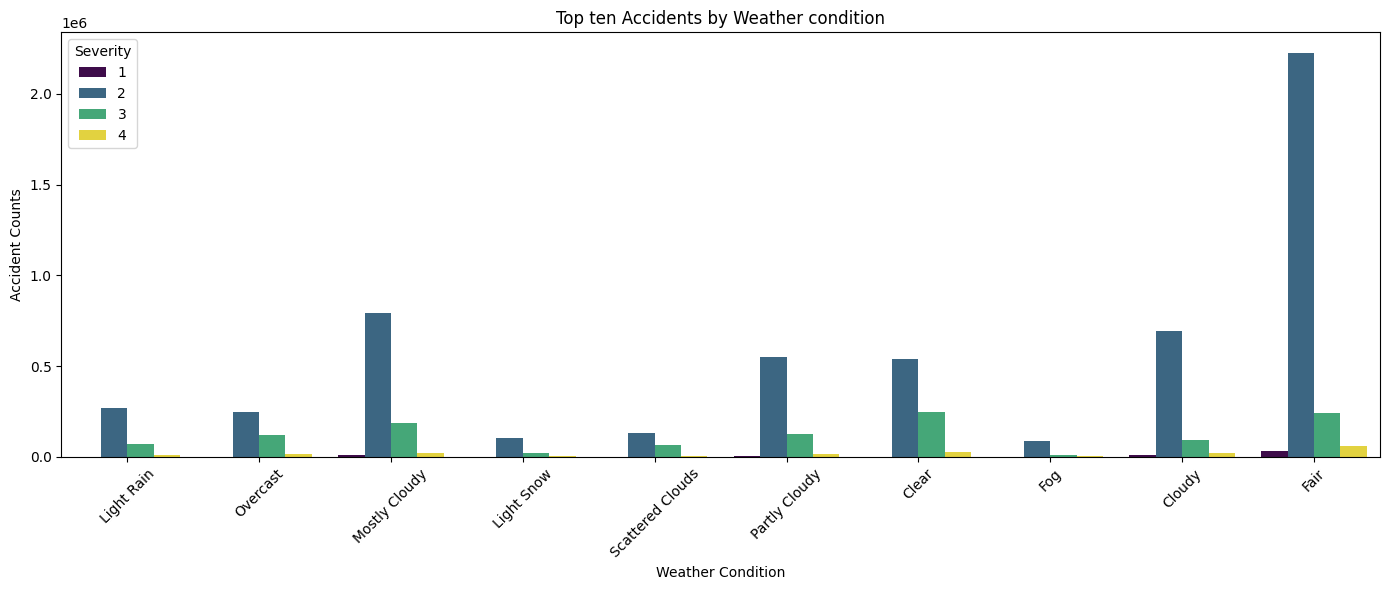

In [71]:

# To filter to make sure the data is plotted is in the top ten
subset = us_accidents_df[us_accidents_df['Weather_Condition'].isin(weather_condition_top_10)]

plt.figure(figsize=(14,6))
sns.countplot(data=subset, x = 'Weather_Condition', hue= "Severity", palette= 'viridis')

plt.title('Top ten Accidents by Weather condition')
plt.xlabel('Weather Condition')
plt.ylabel('Accident Counts')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

In [72]:
from sklearn.feature_extraction.text import TfidfVectorizer
sev4 = us_accidents_df[us_accidents_df['Severity']==4]
tfidf = TfidfVectorizer(stop_words='english')
X = tfidf.fit_transform(sev4['Weather_Condition'].astype(str))

scores = X.sum(axis=0).A1
vocab = tfidf.get_feature_names_out()

top_indices = scores.argsort()[::-1][:20]
top_terms = [(vocab[i], scores[i]) for i in top_indices]

top_terms

[('fair', 60177.36871176483),
 ('cloudy', 55002.42724132078),
 ('clear', 26479.0),
 ('overcast', 13867.0),
 ('partly', 13532.119668451212),
 ('light', 10251.012513945781),
 ('rain', 9675.898872910717),
 ('nan', 7429.0),
 ('snow', 4832.718460266701),
 ('scattered', 4222.134590465093),
 ('clouds', 4222.134590465093),
 ('fog', 2874.3875847994177),
 ('windy', 2464.044892360856),
 ('haze', 1118.0356191905096),
 ('heavy', 1057.7902923425015),
 ('drizzle', 958.201759152357),
 ('thunder', 705.7464765520901),
 ('storm', 541.7195939637999),
 ('smoke', 419.99029613367446),
 ('vicinity', 310.13441745460227)]

In [73]:
weather_terms = ['rain','cloudy','clear','overcast','fair','snow','fog','windy','haze','drizzle','thunder','storm','smoke']
results = {}
for term in weather_terms:
    mask = us_accidents_df['Weather_Condition'].str.contains(term, case=False, na=False)
    total = mask.sum()
    s4 = us_accidents_df[mask]['Severity'].eq(4).sum()
    prob = s4/ total if total > 0 else 0
    results[term] = prob 
results

formatted_weather_terms = {k: round(v, 3) for k, v in results.items()}
formatted_weather_terms

{'rain': 0.026,
 'cloudy': 0.025,
 'clear': 0.033,
 'overcast': 0.036,
 'fair': 0.023,
 'snow': 0.038,
 'fog': 0.027,
 'windy': 0.027,
 'haze': 0.015,
 'drizzle': 0.037,
 'thunder': 0.021,
 'storm': 0.022,
 'smoke': 0.033}

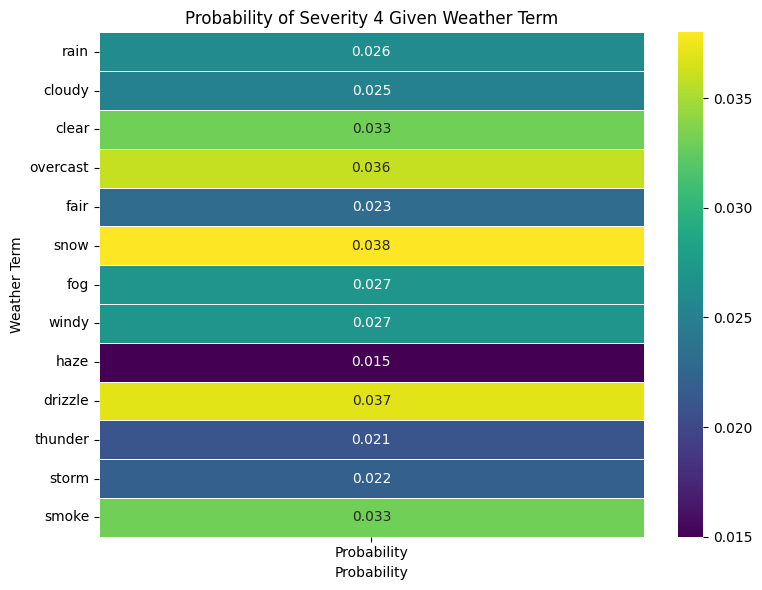

In [74]:
formatted_weather_terms_df = pd.DataFrame.from_dict(formatted_weather_terms, orient='index', columns=['Probability'])

plt.figure(figsize=(8,6))
sns.heatmap(formatted_weather_terms_df, annot=True, cmap = 'viridis', linewidths=.5, fmt=".3f")
plt.title("Probability of Severity 4 Given Weather Term")
plt.ylabel("Weather Term")
plt.xlabel('Probability')
plt.tight_layout()
plt.show()

Based on the data the likelihood the driver accident severity 4 the probability increased the most when it snowing, drizzling, and overcast

## ANOVA TEST

Next Running a ANOVA test to see of visibility differ across severity. 

- To run the ANOVA Test first the data points have to be independence of each other. The accidents have ID representing different accidents

Next making sure that the residuals are normal with a Q-Q plot.

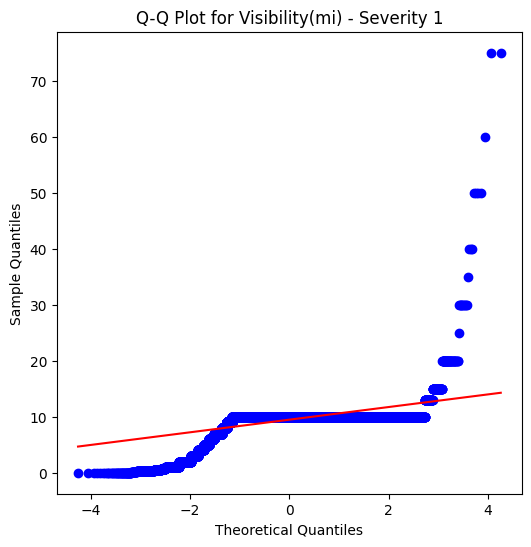

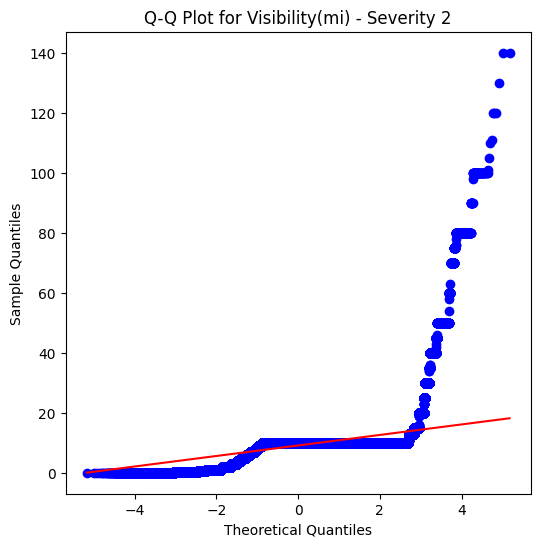

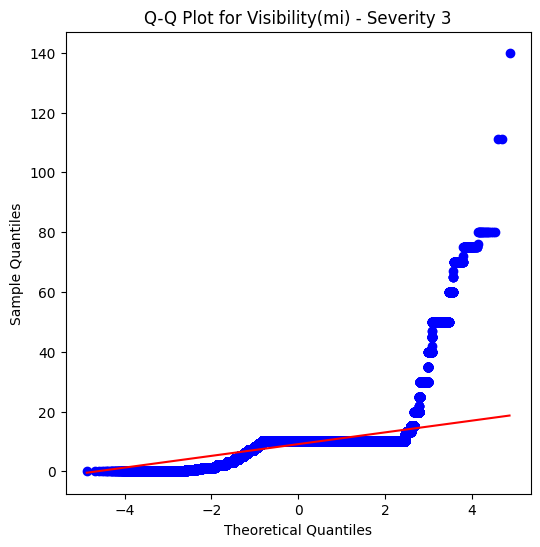

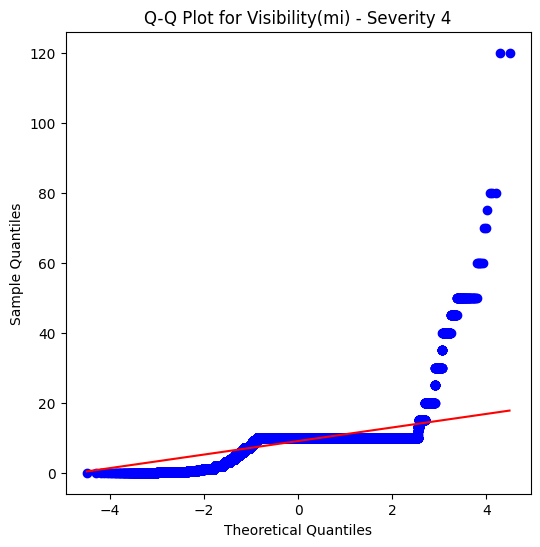

In [75]:
import scipy.stats as stats 
severity_levels = sorted(us_accidents_df['Severity'].unique())

for s in severity_levels:
    group = us_accidents_df[us_accidents_df['Severity']== s]['Visibility(mi)'].dropna()

    plt.figure(figsize=(6,6))
    stats.probplot(group, dist="norm", plot=plt)
    plt.title(f"Q-Q Plot for Visibility(mi) - Severity {s}")
    plt.xlabel("Theoretical Quantiles")
    plt.ylabel("Sample Quantiles")
    plt.show()

The Q-Q plot for visibility (mi) within Severity have a slight deviation toward the left it show there are more very high visibility accidents than normal distribution predicts but ANOVA still be used

Next we have to check for Homogeneity, Levene's test to checks whether all group have similar variance.

In [76]:
from scipy.stats import levene
groups = [
    us_accidents_df[us_accidents_df['Severity']== s]['Visibility(mi)'].dropna()
    for s in sorted(us_accidents_df['Severity'].unique())
]
stat, p = levene(*groups)
stat, p

(1251.2296578430662, 0.0)

The p-value which near zero is violated the equal variance assumption. This means variances of Visibility(mi) are not equal across Severity level. So, Welch's ANOVA (paramertic) can handle the unequal variances. 

The last assumption for the ANOVA test making sure that the dependent variable which is ('Visibility(mi)) is continuous

In [77]:
us_accidents_df['Visibility(mi)'].head(10)

0    10.0
1    10.0
2    10.0
3     9.0
4     6.0
5     7.0
6     7.0
7     7.0
8     5.0
9     3.0
Name: Visibility(mi), dtype: float64

In [78]:
import pingouin as pg

welch = pg.welch_anova(dv='Visibility(mi)', between='Severity', data=us_accidents_df)
welch

,Source,ddof1,ddof2,F,p_unc,np2
0,Severity,3,250521.553898,932.417227,0.0,0.000185


What the welch anova is outputting.
- the p value (p_unc), is very small 0.0 which means there are statistically significant difference across the severity levels
- np2 (effect size) is 0.000185 is small
- The next step is to perform the games- howell test 

In [79]:
gh = pg.pairwise_gameshowell(dv='Visibility(mi)', between='Severity', data=us_accidents_df)
gh

,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges
0,1,2,9.475379,9.086604,0.388774,0.007387,52.630211,6.931687e+04,0.000000,0.148264
1,1,3,9.475379,9.092717,0.382662,0.007766,49.271196,8.462532e+04,0.000000,0.131286
2,1,4,9.475379,9.060768,0.414611,0.009742,42.557896,1.743043e+05,0.000000,0.156503
3,2,3,9.086604,9.092717,-0.006112,0.002837,-2.154605,1.716358e+06,0.136141,-0.002273
4,2,4,9.086604,9.060768,0.025837,0.006530,3.956522,2.083615e+05,0.000442,0.009798
5,3,4,9.092717,9.060768,0.031949,0.006957,4.592650,2.672133e+05,0.000026,0.010845


The Games - Howell post-hoc test was preformed. The data show that Severity 1 had significant higher visibility compared to Severity 2, 3, and 4. Severity 2 and 3 where about the same. Severity 4 accident occur in slightly lower visibility but the effect size is small (hedges column). 

### Where to the Accident take place

In [80]:
cols = ['Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway',
       'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal',
       'Turning_Loop']

true_counts = {col: us_accidents_df[col].value_counts().get(True, 0) for col in cols}
sorted_true_counts = dict(sorted(true_counts.items(), key=lambda x: x[1], reverse=True))
sorted_true_counts


{'Traffic_Signal': 1143772,
 'Crossing': 873763,
 'Junction': 571342,
 'Stop': 214371,
 'Station': 201901,
 'Amenity': 96334,
 'Railway': 66979,
 'Give_Way': 36582,
 'No_Exit': 19545,
 'Traffic_Calming': 7598,
 'Bump': 3514,
 'Roundabout': 249,
 'Turning_Loop': 0}

The Count of the accident data show where do the accident take place. The Data shows that traffic control system like : "Traffic Calming", "Bump", "Roundabout", and "Turning Loop" are very effective in limited accidents. 

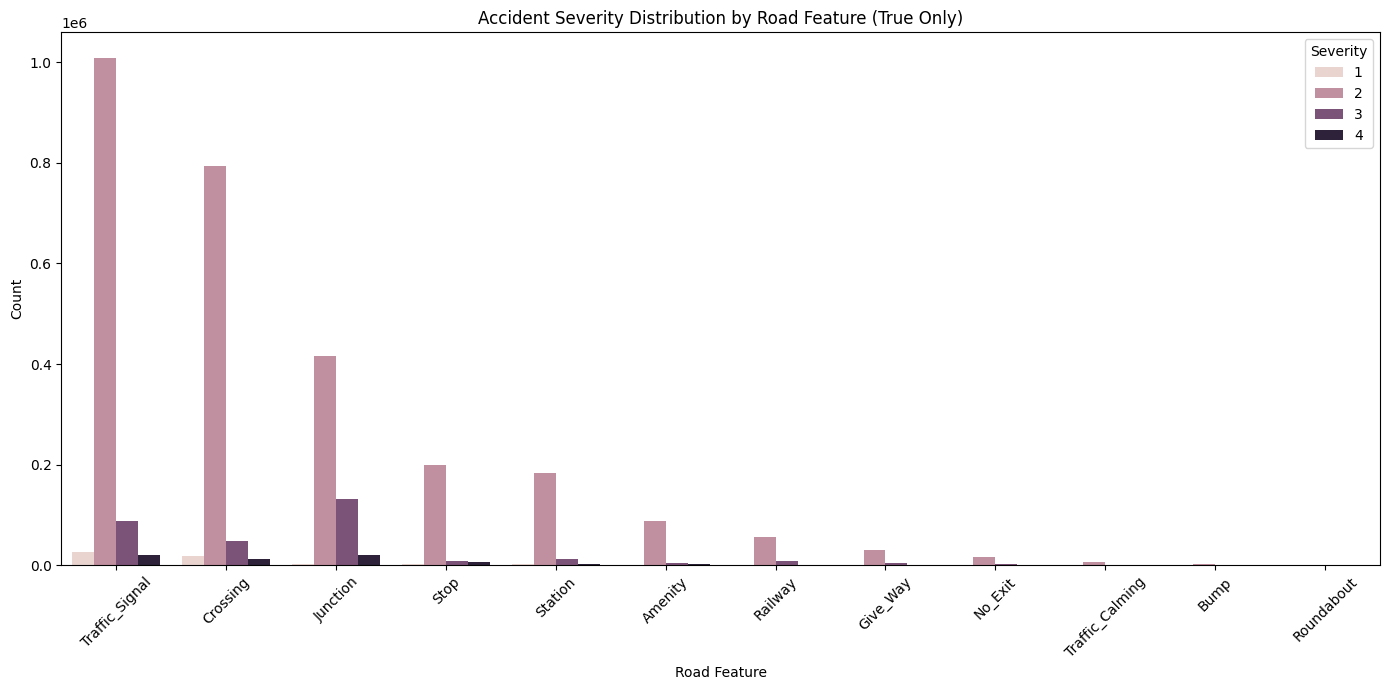

In [81]:
cols = ['Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway',
       'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal',
       'Turning_Loop']

df_melted = us_accidents_df[cols + ['Severity']].melt(
    id_vars='Severity',
    value_vars= cols,
    var_name= 'Feature',
    value_name='Present'
)

df_true = df_melted[df_melted['Present']== True]

plt.figure(figsize=(14,7))
sns.countplot(data = df_true, x= 'Feature', hue = 'Severity', order=df_true['Feature'].value_counts().index)
plt.title("Accident Severity Distribution by Road Feature (True Only)")
plt.xlabel("Road Feature")
plt.ylabel("Count")
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

## Chi squared

Chi-square test of independence for each road feature vs severity. 
To see Do severity distribution change when a road feature is present?
The null hypothesis - There are no relationship between road feature and severity.

In [82]:
from scipy.stats import chi2_contingency
features = ['Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway',
       'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal',
       'Turning_Loop']
results_chi = {}
for f in features:
    table = pd.crosstab(us_accidents_df[f], us_accidents_df['Severity'])
    chi2, p, dof, expected = chi2_contingency(table)
    results_chi[f] = p
results_chi

{'Amenity': 0.0,
 'Bump': 4.7453811090423975e-48,
 'Crossing': 0.0,
 'Give_Way': 1.0365908941568598e-122,
 'Junction': 0.0,
 'No_Exit': 9.242720271400342e-232,
 'Railway': 8.797445165229474e-256,
 'Roundabout': 2.988441582821331e-09,
 'Station': 0.0,
 'Stop': 0.0,
 'Traffic_Calming': 2.899627529908377e-52,
 'Traffic_Signal': 0.0,
 'Turning_Loop': 1.0}

Based on the small p - values on 'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming', and 'Traffic_Signal' we can reject the null hypothesis that there is no relationship between road features and accident severity.
The result shows that all feature except 'Turning_Loop' that road feature are significantly related to accident severity. Next is the Cramers V test to see how big is the relationship between severity and road features. 



In [83]:
import numpy as np
def cramers_v(confusion_matrix):
    chi2 = stats.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2/(n* (min(r,k)-1)))

features = ['Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway',
       'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal',
       'Turning_Loop']

results = {}

for f in features:
    table = pd.crosstab(us_accidents_df['Severity'], us_accidents_df[f])
    results[f] = cramers_v(table.values)

results

/var/folders/ld/31s_plj115d4g7x98gwchs3r0000gn/T/ipykernel_4125/1351712614.py:6: RuntimeWarning: invalid value encountered in divide
  return np.sqrt(chi2/(n* (min(r,k)-1)))


{'Amenity': 0.03883916882090283,
 'Bump': 0.005370420987516219,
 'Crossing': 0.12097103508552068,
 'Give_Way': 0.008570311050598418,
 'Junction': 0.05285395539610915,
 'No_Exit': 0.011769126652983436,
 'Railway': 0.012362802038037173,
 'Roundabout': 0.0023478709904602314,
 'Station': 0.0499623502907452,
 'Stop': 0.060106886715729994,
 'Traffic_Calming': 0.005600281911426843,
 'Traffic_Signal': 0.12113081573771231,
 'Turning_Loop': nan}

The Cramers V test shows the relationship strength score between Severity and road features. The relationship based on the available data is 'Crossing' and 'Traffic Signal, have noticeable effect but not huge. 'Stop', 'Station', and 'Amenity' have very small relationship. 'No Exit', 'Railway', 'Give way', 'Traffic_Calming', 'Bump', and 'Roundabout' have a very weak effect on accident severity.

### Looking Accident by State

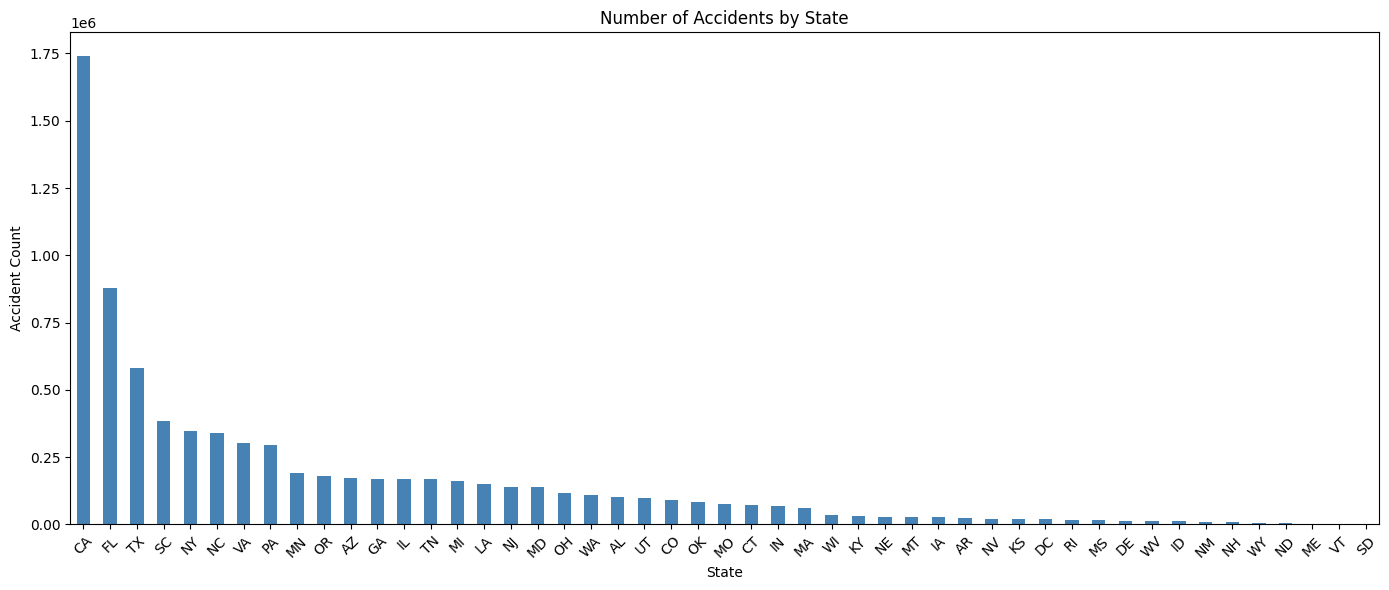

In [84]:
state_counts = us_accidents_df['State'].value_counts()

plt.figure(figsize=(14,6))
state_counts.plot(kind= 'bar', color= 'steelblue')

plt.title('Number of Accidents by State')
plt.xlabel('State')
plt.ylabel('Accident Count')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

Base on the analysis it look like the Accident is base on population that have vehicles. The interesting is South Carolina because one of lest populated state at the time of data collection but have the fourth most accident.

## Look at South Carolina vs the US

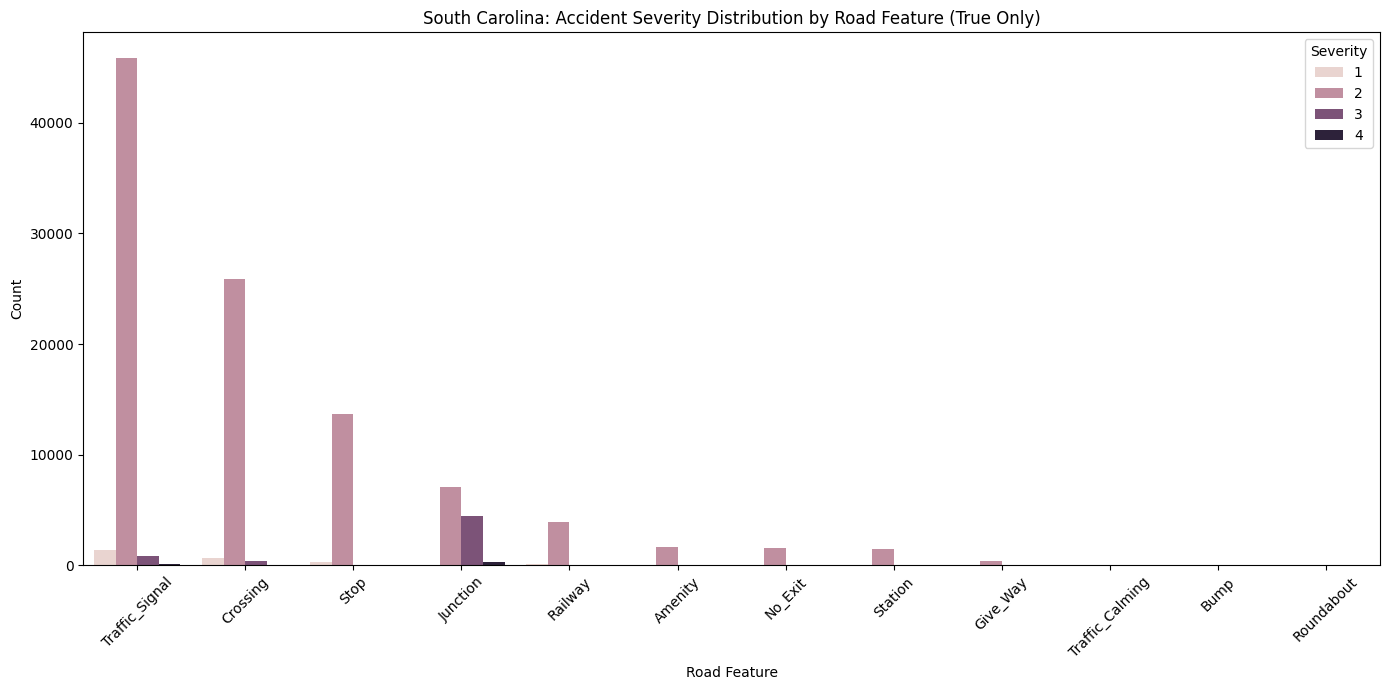

In [ ]:
sc_df = us_accidents_df[us_accidents_df['State'] == 'SC']

cols = ['Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway',
       'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal',
       'Turning_Loop']

sc_melted = sc_df [cols + ['Severity']].melt(
    id_vars='Severity',
    value_vars= cols,
    var_name= 'Feature',
    value_name='Present'
)

sc_true = sc_melted[sc_melted['Present']== True]

plt.figure(figsize=(14,7))
sns.countplot(data = sc_true, x= 'Feature', hue = 'Severity', order=sc_true['Feature'].value_counts().index)
plt.title("South Carolina:Accident Severity Distribution by Road Feature (True Only)")
plt.xlabel("Road Feature")
plt.ylabel("Count")
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

Junction Severity 3 highest value 

In [86]:
sc_df = us_accidents_df[us_accidents_df['State'] == 'SC']
cols = ['Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway',
       'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal',
       'Turning_Loop']
us_feature_rates = us_accidents_df[cols].mean().sort_values(ascending=False)
sc_feature_rates = sc_df[cols].mean().sort_values(ascending=False)

compare_df = pd.DataFrame({
    'US': us_feature_rates,
    'South Carolina': sc_feature_rates
})

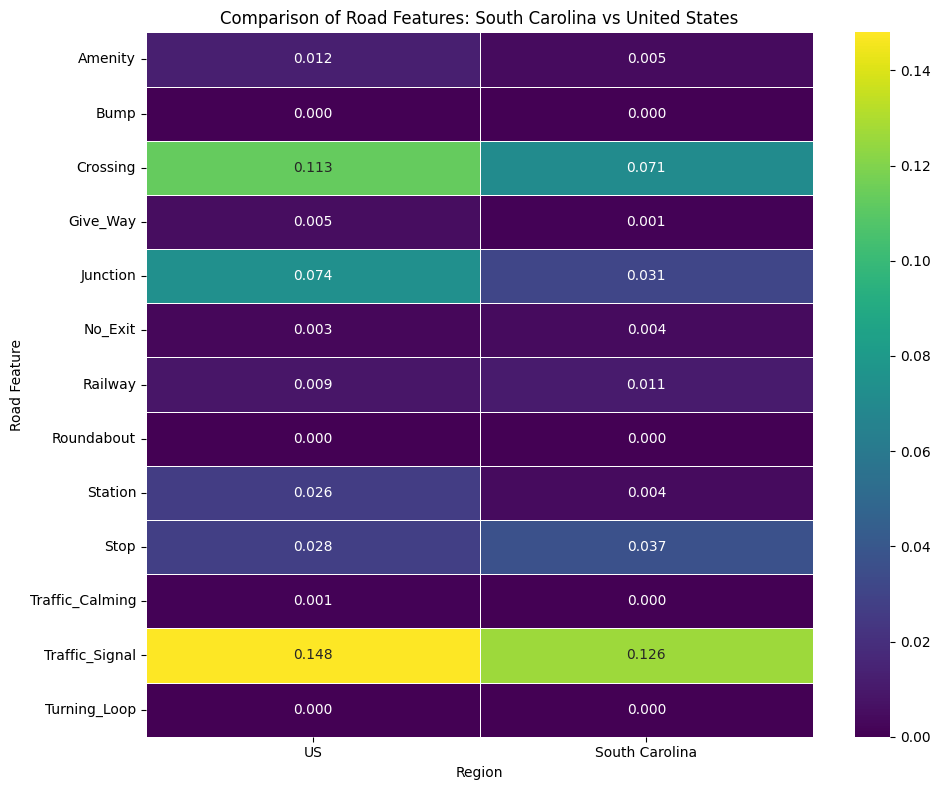

In [87]:
plt.figure(figsize=(10, 8))
sns.heatmap(compare_df, annot=True, cmap='viridis', fmt= ".3f", linewidths = .5)
plt.title("Comparison of Road Features: South Carolina vs United States")
plt.xlabel("Region")
plt.ylabel("Road Feature")
plt.tight_layout()
plt.show()

For accidents that happens in South Carolina "Railway", "Stop", "No Exit" are higher then US average.

## Accident by time 

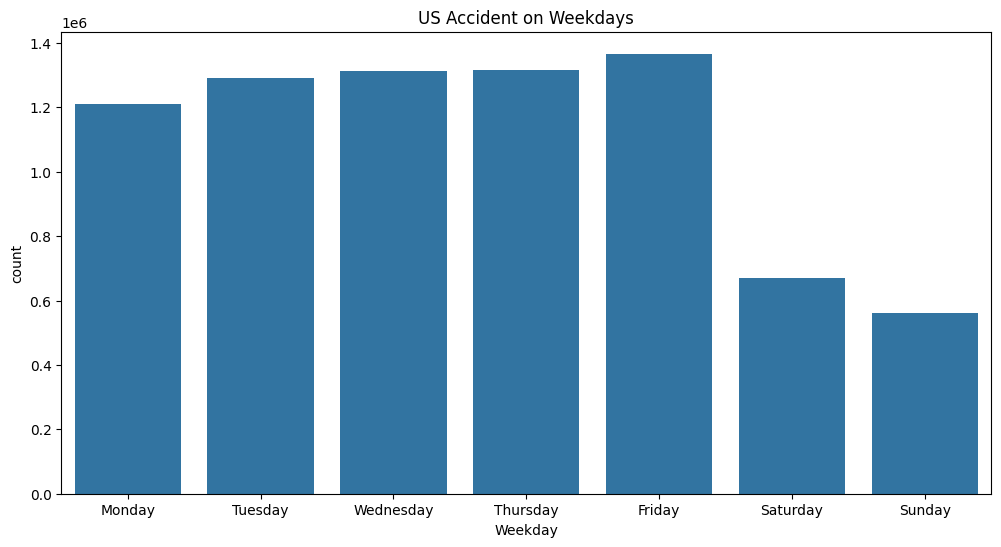

In [88]:
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
plt.figure(figsize=(12,6))
sns.countplot(data=us_accidents_df, x= 'Weekday', order=order)
plt.title('US Accident on Weekdays')
plt.show()

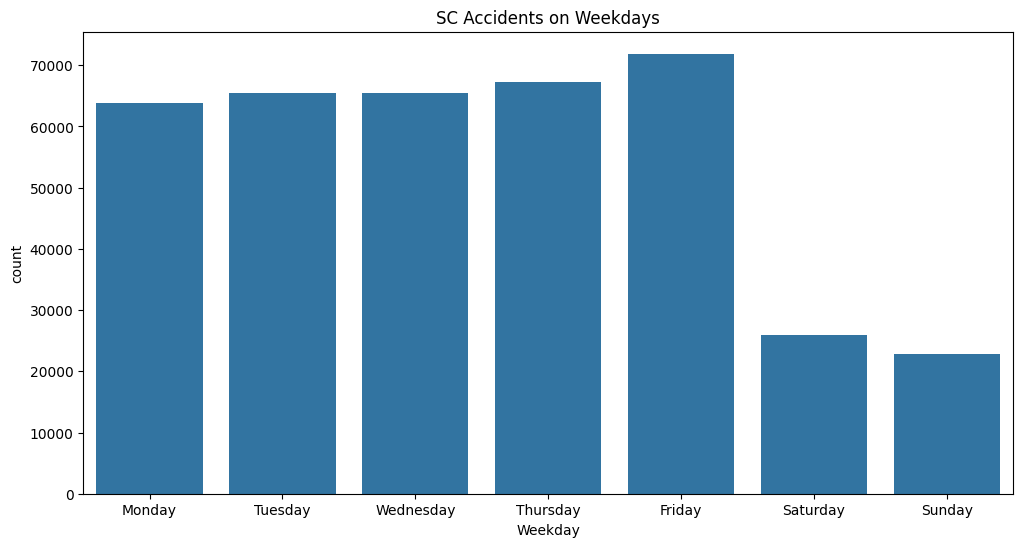

In [89]:
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sc_df = us_accidents_df[us_accidents_df['State'] == 'SC']
plt.figure(figsize=(12,6))
sns.countplot(data= sc_df, x= 'Weekday', order=order)
plt.title('SC Accidents on Weekdays')
plt.show()

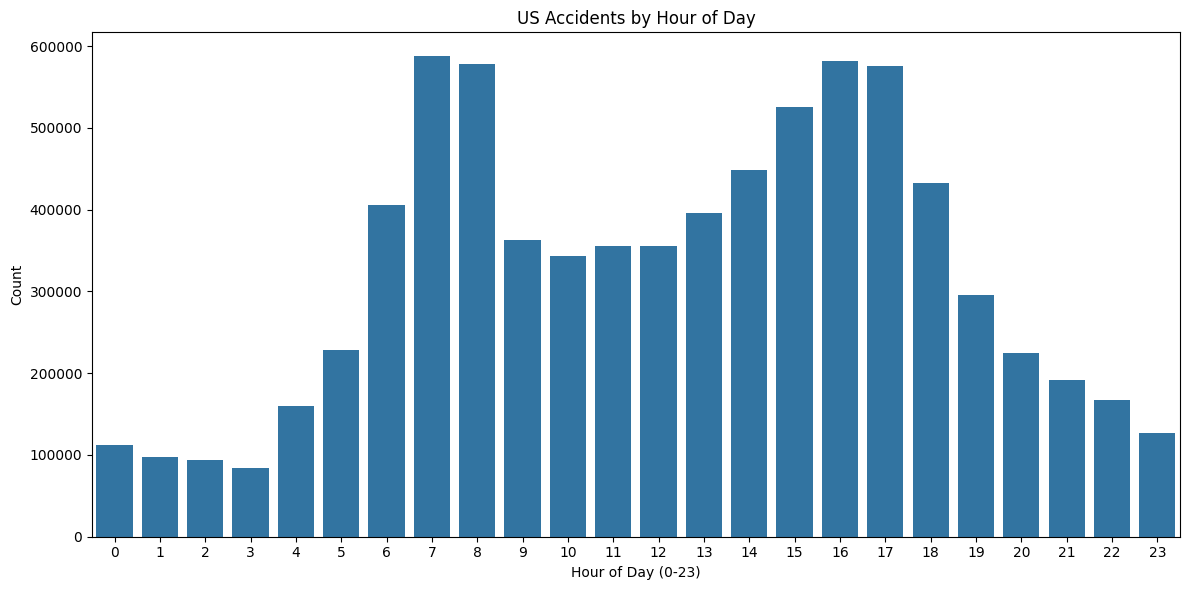

In [90]:
plt.figure(figsize=(12,6))
sns.countplot(data=us_accidents_df, x='Hour', order= range(24))
plt.title("US Accidents by Hour of Day")
plt.xlabel("Hour of Day (0-23)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

As expected the hours of the day accident that are counted thought the dataset is near rush hours 6 - 9 in the morning. 

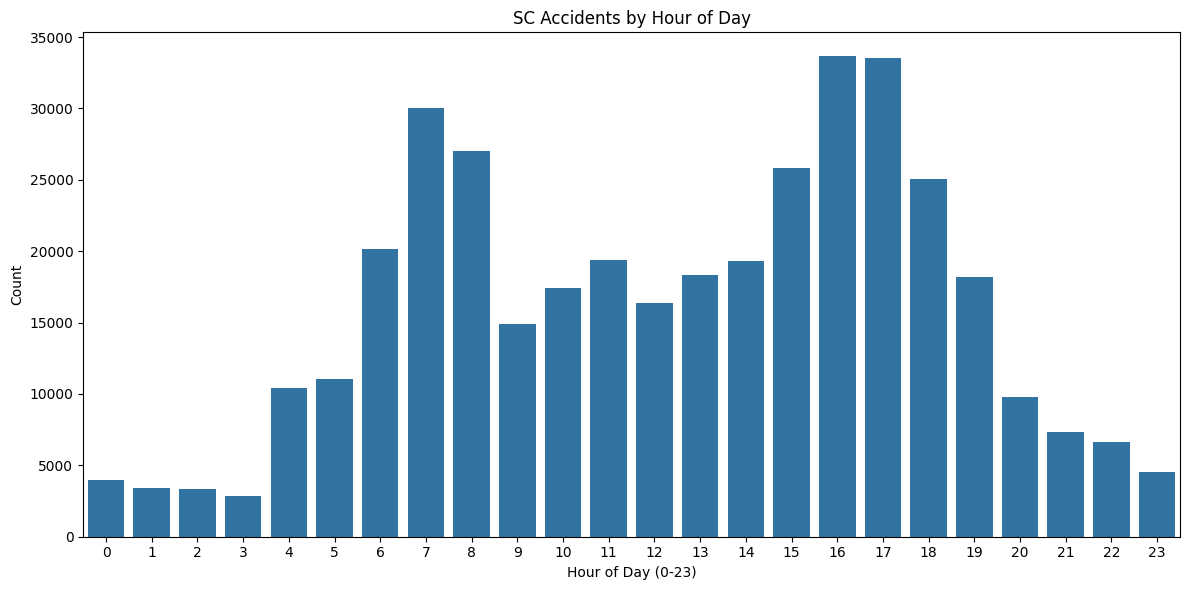

In [91]:
sc_df = us_accidents_df[us_accidents_df['State'] == 'SC']
plt.figure(figsize=(12,6))
sns.countplot(data=sc_df, x='Hour', order= range(24))
plt.title("SC Accidents by Hour of Day")
plt.xlabel("Hour of Day (0-23)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

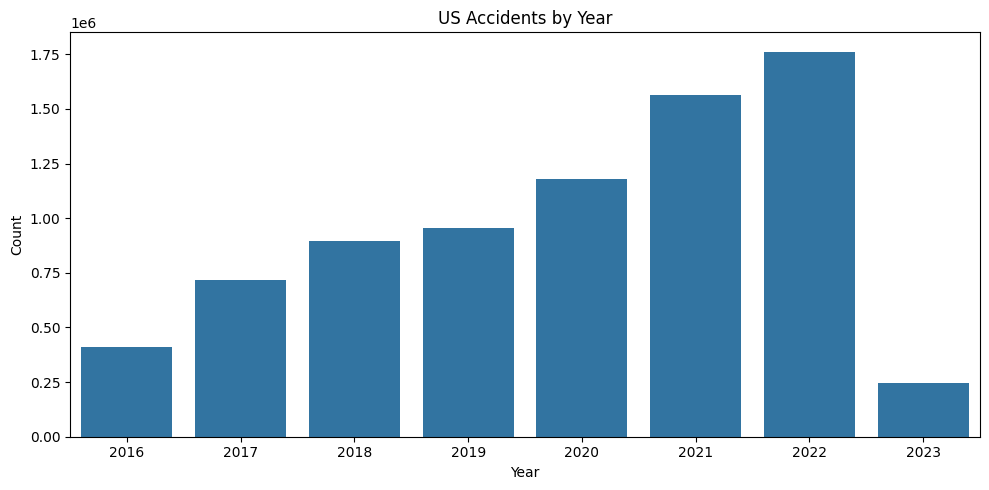

In [92]:
plt.figure(figsize=(10,5))
sns.countplot(data=us_accidents_df, x="Year", order=sorted(us_accidents_df['Year'].unique()))
plt.title("US Accidents by Year")
plt.xlabel('Year')
plt.ylabel("Count")
plt.tight_layout()
plt.show()

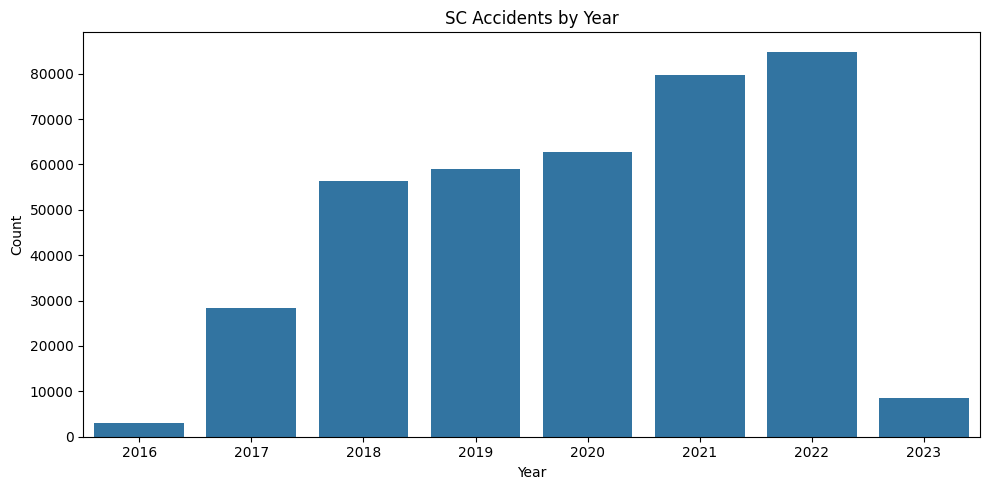

In [93]:
sc_df = us_accidents_df[us_accidents_df['State'] == 'SC']
plt.figure(figsize=(10,5))
sns.countplot(data=sc_df , x="Year", order=sorted(sc_df['Year'].unique()))
plt.title("SC Accidents by Year")
plt.xlabel('Year')
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [94]:
us_accidents_df[['Start_Time']].sort_values(by='Start_Time').head()

,Start_Time
3548807,2016-01-14 20:18:33
3548830,2016-01-14 20:18:33
3562358,2016-01-14 20:18:33
3562512,2016-01-14 20:18:33
3571330,2016-01-14 20:18:33


The Dataset begins in January 14 at 8pm. 

In [95]:
us_accidents_df[['Start_Time']].sort_values(by='Start_Time').tail()

,Start_Time
3649166,2023-03-31 23:18:00
3665682,2023-03-31 23:19:00
3647141,2023-03-31 23:21:00
3659354,2023-03-31 23:25:30
3662007,2023-03-31 23:30:00


The Dataset end in March of 2023 that impact the total count for the year 2023.

## Export to CSV

In [96]:
us_accidents_df.to_csv('Data/us_accidents.csv', index=False)


## Evaluation

### Business Insight/Recommendation 1

The Accident dataset shows that there a relationship between visibility and certain weather conditions, but the difference is slight. The data shows that highest visibility had Severity 1 accidents and lowest visibility in Severity 4 accidents showing that obstructing the driver's vision can lead to more devastating crashes. Although the effect is very small, the patten can be seen across multiple tests showing the relationship that the likelihood of Severity increases when the visibility decreases. The Weather Condition text also show this with 'Snow'(0.038), 'drizzle'(0.036), and overcast (0.036) and smoke (0.033) have the highest probability in Severity 4 accident then higher visibility like fair(0.023). These difference are not that dramatic but the patterns can be seen.
My recommendation is that the DOT should prioritize enhancing drivers vision by installing dynamic video board signs to remind the drivers to slowdown during snow, drizzle, and fog. Having updated reflective marking can be effective in increasing the driver's vision. DOT can strengthen roads for snowing condition with brine. Local navigation apps can have better route based on weather-severity risk.

### Business Insight/Recommendation 2

Based on the Dataset, Chi square test, and Cramers V to see how strong the relationship between severity and road features. The traffic feature have small effect sizes with Cramers V but there is still a pattern them. The strongest association with severity is 'Traffic Signal' (V = 0.121), 'Crossing' (V = 0.121), 'Stop'(V= 0.060), 'Junction' (V= 0.053). Based on the cart 'Accident Severity Distribution by Road Feature' it shows there are more accidents in a place that requires judgement compared to road features that have control measures in place ('Bump', 'Traffic Calming', 'Roundabout', and 'Give Way'). These features have weak relationships with severity because it slow the traffic down naturally giving less likely to have high severity accidents. My recommendation is to add protected left and right turns to allow drivers a chance to make their turn more safely. Update Traffic signal timing some cities population are growing faster and failed to update their Traffic signal it can lead to red light runners. Adding more traffic features like 'Bump', 'Traffic Calming', 'Roundabout', and 'Give Way' the data showed it works very well in controlling traffic flow.

### Business Insight/Recommendation 3

Based on the Dataset South Carolina is the four most state that have accident occurrence despite have one of the lowest population in the US. South Carolina mirrors The US in weekday traffic accidents, accident per hour, and accident per year. Key difference is the road features in South Carolina vs The US. 'Stop' (SC: 0.037, US: 0.028), 'Railway Crossing' (SC: 0.011, US: 0.009), and 'No exit' (SC: 0.004, US: 0.003). But South Carolina is below average in the 'Traffic Signals' (US: 0.148, SC: 0.126), 'Crossing'(US:0.148, SC:0.071) meaning that South Carolina is more rural it makes sense because one of the less populated states in the US. My recommendation for South Carolina DOT is to focus on upgrading 'Junctions'. The US and South Carolina Junction Severity 2 is higher vs Severity 3 but South Carolina is unusually high compare to other features in the states. Putting 'Bump', 'Traffic Calming', 'Roundabout', in higher speed at 'Junction' it will control the speed to lower the risk of accidents.

### Tableau Dashboard link

https://public.tableau.com/views/USaccidents_17741362268570/AccidentsaroundtheUS?:language=en-US&publish=yes&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link

## Conclusion and Next Steps


This analysis shows many factors in US traffic accident patterns and severity levels with a focus on South Carolina. Several Features showed across weather, visibility, and road features.

First, the data discovered that reduction in visibility and weather condition like snow, fog, and overcast skies was associated with higher chance of getting into a severe crash. Even though the effect size is low multiple test and chart show that same pattern of small reduction of visibility will increase the severity risk.

Second, the data discovered that road features had a statistically significant relationship with severity. 'Traffic Signal', 'Crossing', 'Stop', and 'Junctions'. These areas have a lot of high traffic decision making drivers. Features like 'Bump', 'Traffic Calming', 'Roundabout', and 'Give Way' make for less risky way for drivers to get to their destination.

Finally, The data that compared South Carolina and the US traffic data had some good insights. For the daily patterns South Carolina fit with the US pattern, like weekend was less likely to get into an accident and doing rush hour is more likely to get into an accident. South Carolina did have some difference like more crashes at 'Stop', 'Railway Crossing', and 'No exit' then the US. Also Junction in South Carolina had a higher proportion the US in severity 3.

Next steps is making a predictive model like Random Forest, XGBoost, or Logistic Regression in helping insurance and emergency response team stakeholders. Mapping coordinates for South Carolina junction that South Carolina DOT can identify to upgrade. Get the average speed data to see if the limit can be adjusted. 